<div class="alert alert-block alert-info">
<center><strong> Predicting Urban vs. Rural Household Classification using Supervised Machine Learning </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | text  |
| Llanes, Andre Gabriel De Ocampo  | text  |
| Rojo, Von Matthew De Guzman *(leader)* | text |
| Tan, Jeremy James Teves | text |

Professor: Antioquia, Arren Matthew Capuchino

**Project Objective:** The primary objective of this project is to develop and evaluate supervised machine learning models capable of predicting whether a family resides in an Urban or Rural area (URB).
<br/><br/>
This project utilizes a comprehensive set of socioeconomic and structural features from the Family Income and Expenditure Survey (FIES) dataset, including:
* **Housing Characteristics:** Building type, roof material, wall material, toilet facilities, electricity access, and main water source.
* **Financial Indicators:** Total income, total expenditures, food and non-food expenses, and rent values (actual and imputed).
* **Asset Ownership:** Quantities of owned assets such as cars, televisions, personal computers, air conditioners, and other household appliances.
<br/><br/>

**Methodology:** As part of the STINTSY Major Course Output (MCO), we will perform end-to-end machine learning pipeline development, starting with Data Preparation and Exploratory Data Analysis (EDA). Ultimately, we will implement and compare the performance of at least three supervised machine learning models (two classical machine learning models and one neural network) to determine the most effective approach for this classification task.
<hr/>

In [1]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

%load_ext autoreload
%autoreload 2
from MCO_functions import *

# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [2]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


Use only selected features to lessen size

In [3]:
selected_features = [
    'URB', # Target Variable
    'W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER',
    'NET_RECEIPT', 'REGFT', 'EAINC', 'TOINC', 'T_FOOD_HOME', 'T_FOOD', 
    'T_CLOTH', 'T_HEALTH', 'T_HOUSING_WATER', 'T_RENTVAL', 'T_IMPUTED_RENT', 
    'T_COMMUNICATION', 'T_BREAD', 'T_MEAT', 'T_FISH', 'T_MILK', 'T_OIL', 'T_FRUIT', 
    'T_VEG', 'T_SUGAR', 'T_FOOD_NEC', 'T_COFFEE', 'T_MINERAL', 'T_NFOOD', 
    'T_TOTEX', 'T_TOTDIS', 'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 
    'LANDLINE_QTY', 'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

fies_subset_df = fies_original_df[selected_features].copy()
fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,,,01,,02,01,01,,01,01
1,2,14,1,5,5,3,1,1,1350,369,...,,01,,,03,01,01,,,
2,2,14,2,1,1,1,1,1,1625,14830,...,01,,,,01,01,01,01,,01
3,2,14,1,1,1,1,1,6,7649,29394,...,,,,,02,01,01,,02,01
4,2,14,1,1,1,1,1,1,7359,130,...,,01,,,01,01,01,,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,00,00,00,00,02,01,01,00,00,00
40167,2,12,1,1,1,0,1,2,0,620,...,00,00,00,00,01,01,00,00,00,00
40168,2,12,1,2,2,0,1,2,1170,540,...,00,00,00,00,01,01,01,00,00,00
40169,2,12,1,1,1,2,1,2,1664,0,...,00,00,00,00,02,01,01,00,00,00


Some data cleaning... puro 01 at 00 yung PC_QTY and others.

In [4]:
qty_columns = [
    'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 
    'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

# Clean and convert the columns
for col in qty_columns:
    # Convert to string, strip whitespace, and replace empty strings with '0'
    fies_subset_df[col] = fies_subset_df[col].astype(str).str.strip().replace('', '0')
    
    # Convert the column to numeric. Any weird unparseable values become NaN (errors='coerce')
    fies_subset_df[col] = pd.to_numeric(fies_subset_df[col], errors='coerce')
    
    # Fill any remaining NaNs with 0, then cast the whole column to integer
    fies_subset_df[col] = fies_subset_df[col].fillna(0).astype(int)

fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,0,0,1,0,2,1,1,0,1,1
1,2,14,1,5,5,3,1,1,1350,369,...,0,1,0,0,3,1,1,0,0,0
2,2,14,2,1,1,1,1,1,1625,14830,...,1,0,0,0,1,1,1,1,0,1
3,2,14,1,1,1,1,1,6,7649,29394,...,0,0,0,0,2,1,1,0,2,1
4,2,14,1,1,1,1,1,1,7359,130,...,0,1,0,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,0,0,0,0,2,1,1,0,0,0
40167,2,12,1,1,1,0,1,2,0,620,...,0,0,0,0,1,1,0,0,0,0
40168,2,12,1,2,2,0,1,2,1170,540,...,0,0,0,0,1,1,1,0,0,0
40169,2,12,1,1,1,2,1,2,1664,0,...,0,0,0,0,2,1,1,0,0,0


check for null values or whitespaces

In [5]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_subset_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()

print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
URB                0
W_REGN             0
BLDG_TYPE          0
ROOF               0
WALLS              0
TOILET             0
ELECTRIC           0
WATER              0
NET_RECEIPT        0
REGFT              0
EAINC              0
TOINC              0
T_FOOD_HOME        0
T_FOOD             0
T_CLOTH            0
T_HEALTH           0
T_HOUSING_WATER    0
T_RENTVAL          0
T_IMPUTED_RENT     0
T_COMMUNICATION    0
T_BREAD            0
T_MEAT             0
T_FISH             0
T_MILK             0
T_OIL              0
T_FRUIT            0
T_VEG              0
T_SUGAR            0
T_FOOD_NEC         0
T_COFFEE           0
T_MINERAL          0
T_NFOOD            0
T_TOTEX            0
T_TOTDIS           0
CAR_QTY            0
MOTORCYCLE_QTY     0
PC_QTY             0
LANDLINE_QTY       0
CELLPHONE_QTY      0
TV_QTY             0
RADIO_QTY          0
AIRCON_QTY         0
WASH_QTY           0
REF_QTY            0


check for any duplicates

In [6]:
# check if there are any duplicates
dupes = fies_subset_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2]** Exploratory Data Analysis (EDA)
This phase allows exploration of datasets and check any anomalies present.
1. Basic Dataset Information
2. Urban and Rural Comparative Statistics

# **[2.1]** Basic Dataset Information
- column statistics

In [7]:
# summary for all columns
description = fies_subset_df.describe().T
print(description.to_string())

                   count           mean            std     min      25%       50%       75%         max
URB              40171.0       1.617311       0.486049     1.0      1.0       2.0       2.0         2.0
W_REGN           40171.0      13.019890      11.995555     1.0      6.0      10.0      14.0        42.0
BLDG_TYPE        40171.0       1.087949       0.388863     1.0      1.0       1.0       1.0         6.0
ROOF             40171.0       1.377760       0.894712     1.0      1.0       1.0       1.0         7.0
WALLS            40171.0       1.641607       1.125698     1.0      1.0       1.0       2.0         7.0
TOILET           40171.0       1.718130       1.539145     0.0      1.0       1.0       2.0         7.0
ELECTRIC         40171.0       1.131563       0.338019     1.0      1.0       1.0       1.0         2.0
WATER            40171.0       3.186030       2.405758     1.0      1.0       3.0       4.0        12.0
NET_RECEIPT      40171.0    2924.002713    4302.292834     0.0  

# **[2.2]** Urban and Rural Comparative Statistics
- income and expenditure distribution
- regional distribution
- household composition

 ### **1.) Income and Expenditure Distribution** 

In [8]:
columns = fies_subset_df.columns

T_columns = [col for col in columns if col.startswith("T_")] # categories

income_prefixes = ("NET_", "REGFT", "EAINC", "TOINC")
NET_columns = [col for col in columns if col.upper().startswith(income_prefixes)] # categories


rural_df =  fies_subset_df[fies_subset_df["URB"] == 2]
urban_df = fies_subset_df[fies_subset_df["URB"] == 1]

# Monthly expenses categories
rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()

# Income and receipts categories
rural_NET_df = rural_df[NET_columns]
urban_NET_df = urban_df[NET_columns]

rural_NET_mean_sr = rural_NET_df.mean()
urban_NET_mean_sr = urban_NET_df.mean()

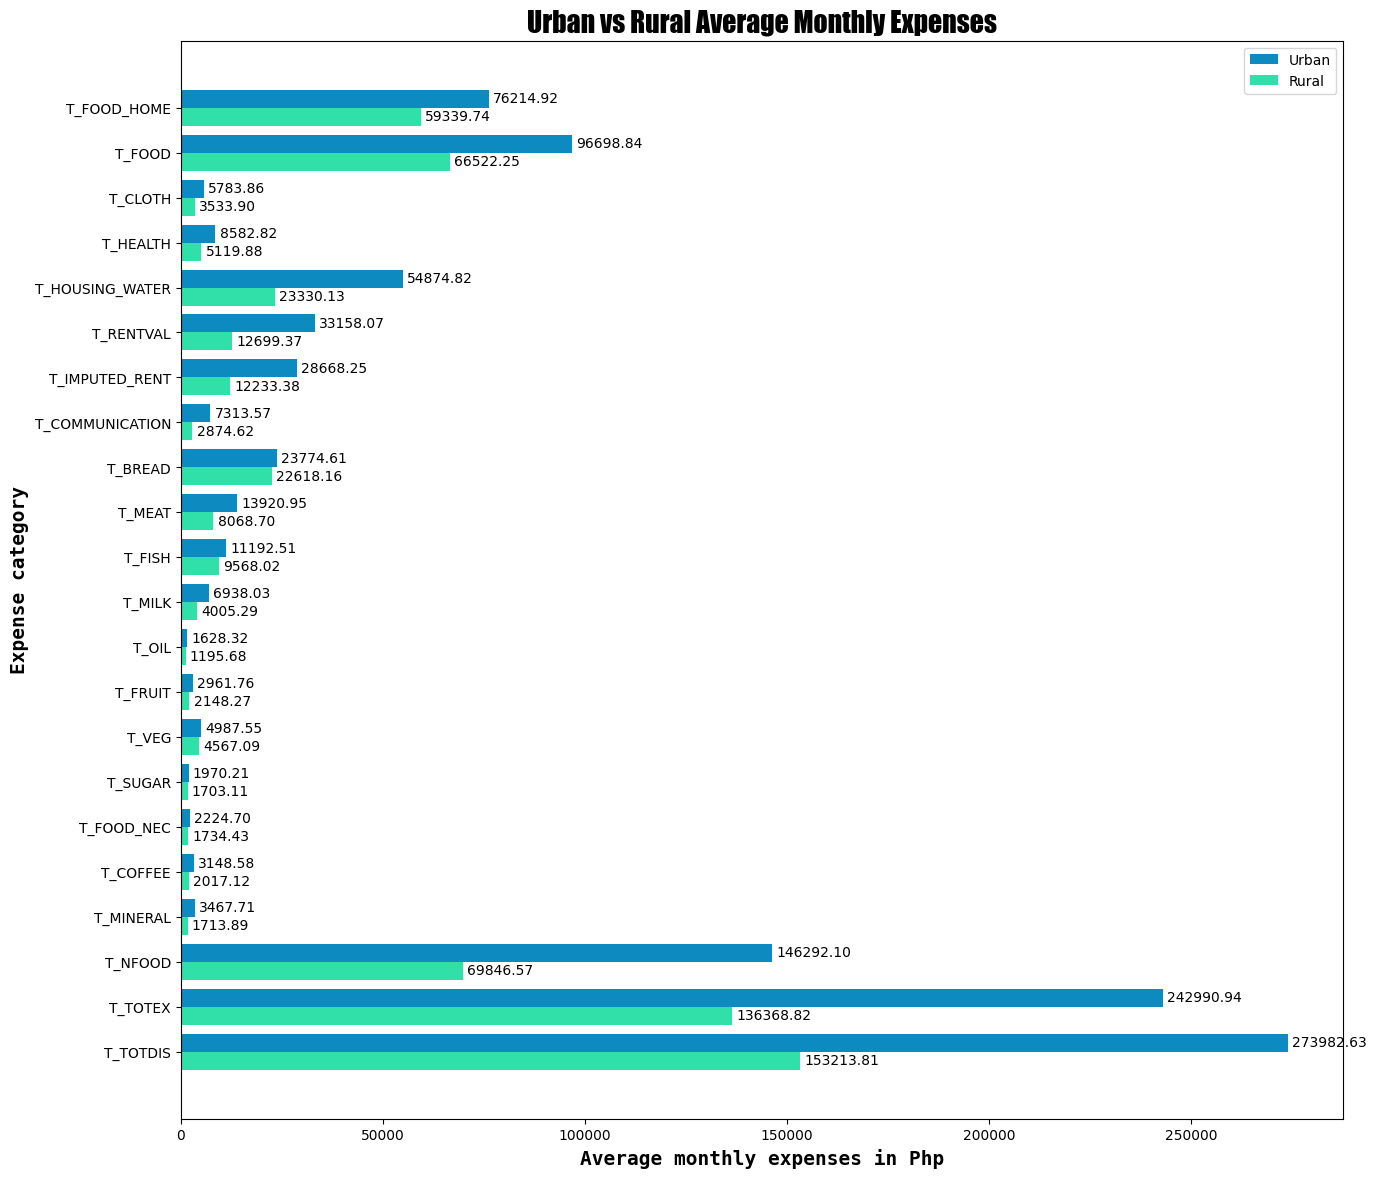

In [9]:
# Compare the average monthly expenses of urban and rural households
compareChart(
    mode="T", # expense
    n=len(T_columns), 
    cat=T_columns, 
    figwidth=15, 
    figheight=14, 
    urban_columns=urban_T_mean_sr.values, 
    rural_columns=rural_T_mean_sr.values, 
    title="Urban vs Rural Average Monthly Expenses"
)

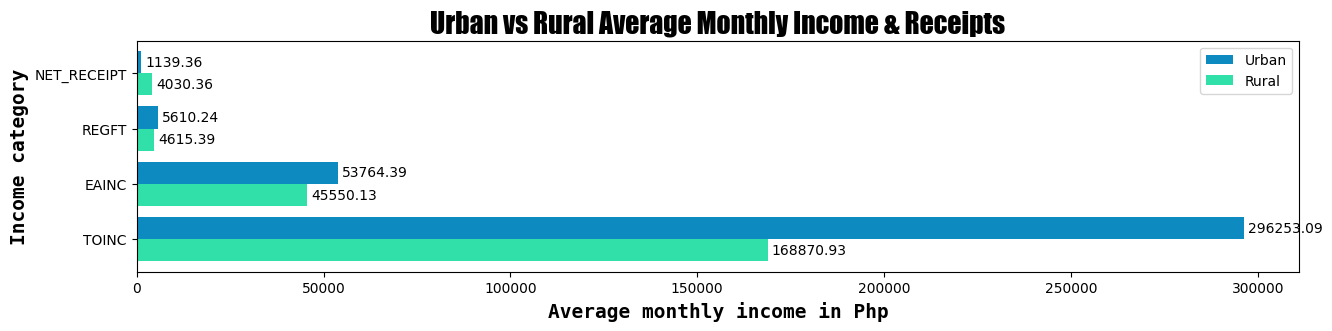

In [10]:
# Compare the average monthly income and receipts of urban and rural households
compareChart(
    mode="N", # income
    n=len(NET_columns), 
    cat=NET_columns, 
    figwidth=15, 
    figheight=3,
    urban_columns=urban_NET_mean_sr.values, 
    rural_columns=rural_NET_mean_sr.values, 
    title="Urban vs Rural Average Monthly Income & Receipts"
)

 ### **2.) Regional Distribution** 

In [11]:

# ── Label mappings ────────────────────────────────────────────────────────────
REGION_LABELS = {
    1:  "Region I\n(Ilocos)",         2:  "Region II\n(Cagayan Valley)",
    3:  "Region III\n(C. Luzon)",     5:  "Region V\n(Bicol)",
    6:  "Region VI\n(W. Visayas)",    7:  "Region VII\n(C. Visayas)",
    8:  "Region VIII\n(E. Visayas)",  9:  "Region IX\n(Zamboanga)",
    10: "Region X\n(N. Mindanao)",    11: "Region XI\n(Davao)",
    12: "Region XII\n(SOCCSKSARGEN)", 13: "NCR",
    14: "CAR",                        15: "ARMM",
    16: "CARAGA",                     41: "Region IVA\n(CALABARZON)",
    42: "Region IVB\n(MIMAROPA)",
}
BLDG_LABELS  = {1:"Single House", 2:"Duplex", 3:"Multi-unit", 4:"Commercial/Industrial", 5:"Makeshift", 6:"Other"}
ROOF_LABELS  = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
WALLS_LABELS = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
TOILET_LABELS= {0:"None", 1:"Water-sealed (own)", 2:"Water-sealed (shared)", 3:"WS Other (own)", 4:"WS Other (shared)", 5:"Closed Pit", 6:"Open Pit", 7:"Others"}
ELECTRIC_LABELS = {1:"Yes", 2:"No"}
WATER_LABELS = {
    1:"Comm. Faucet (own)", 2:"Comm. Faucet (shared)", 3:"Deep Well (own)",
    4:"Deep Well (shared)", 5:"Shallow Well", 6:"Dug Well",
    7:"Protected Spring", 8:"Unprotected Spring", 9:"Lake/River/Rain",
    10:"Peddler", 11:"Bottled", 12:"Others"
}

urban_c, rural_c = "#0d8ac0", "#30e0a8"

# Apply readable labels to a working copy
fies_subset_df_labeled = fies_subset_df.copy()
fies_subset_df_labeled["URB_LABEL"]   = fies_subset_df_labeled["URB"].map({1:"Urban", 2:"Rural"})
fies_subset_df_labeled["REGION_LABEL"]= fies_subset_df_labeled["W_REGN"].map(REGION_LABELS)


print("Label mappings ready.")


Label mappings ready.


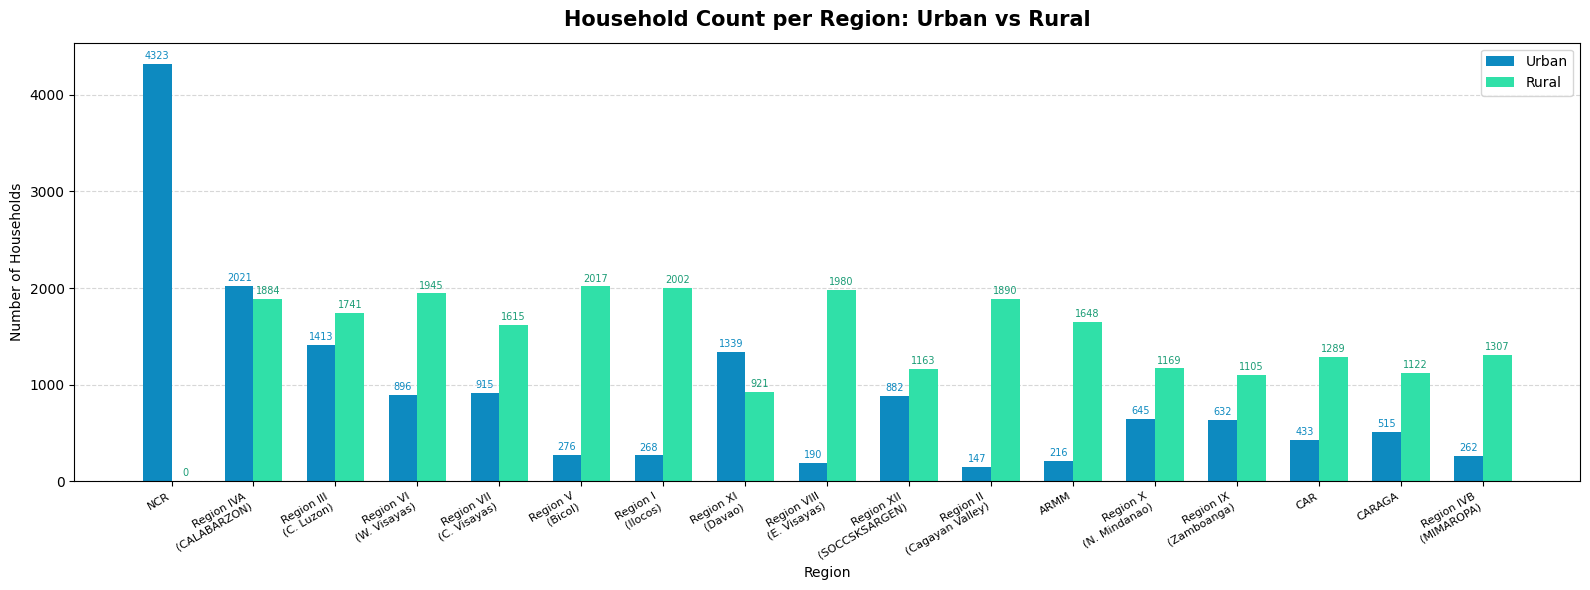

In [12]:

# ── Regional counts: Urban vs Rural ─────────────────────────────────────────
region_urb = (
    fies_subset_df_labeled
    .groupby(["REGION_LABEL", "URB_LABEL"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["Urban", "Rural"]:
    if col not in region_urb.columns:
        region_urb[col] = 0

region_urb["Total"] = region_urb["Urban"] + region_urb["Rural"]
region_urb = region_urb.sort_values("Total", ascending=False)

# ── Plot 1: Grouped bar — raw counts ────────────────────────────────────────
regions = region_urb.index.tolist()
x       = np.arange(len(regions))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
b_u = ax.bar(x - bar_w/2, region_urb["Urban"], bar_w, label="Urban", color=urban_c)
b_r = ax.bar(x + bar_w/2, region_urb["Rural"],  bar_w, label="Rural",  color=rural_c)

for bar in b_u:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color=urban_c)
for bar in b_r:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#1a9c75")

ax.set_title("Household Count per Region: Urban vs Rural", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_xlabel("Region"); ax.set_ylabel("Number of Households")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


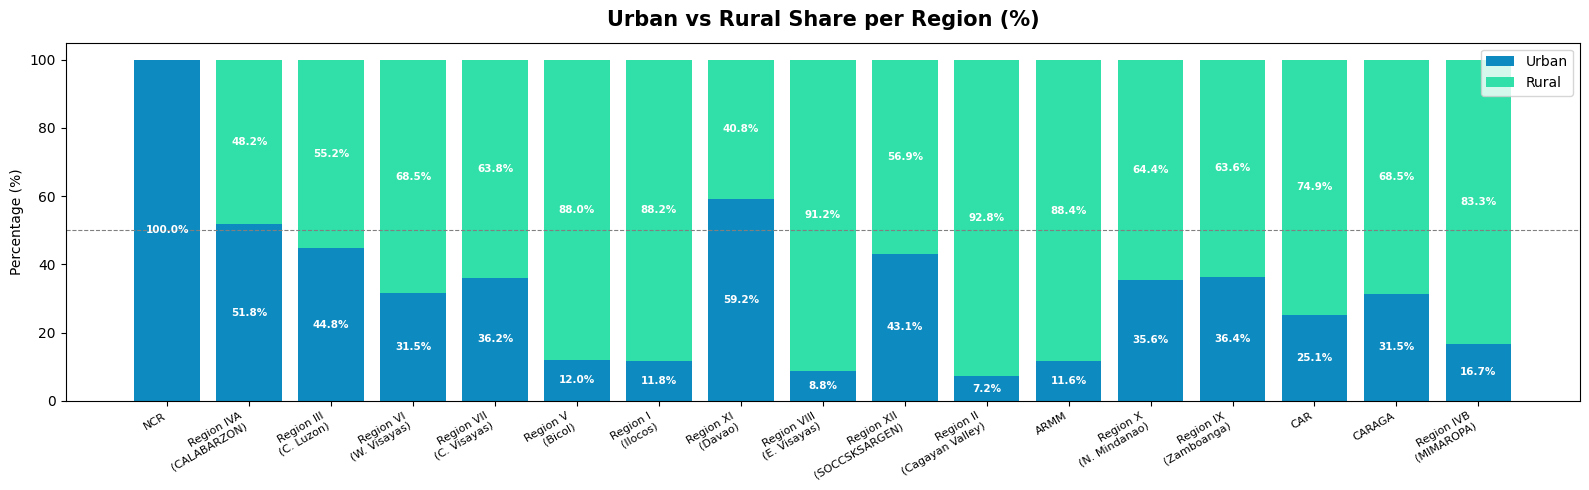


Region                             Urban   Rural   Total  %Urban  %Rural
────────────────────────────────────────────────────────────────────
NCR                                 4323       0    4323   100.0     0.0
Region IVA (CALABARZON)             2021    1884    3905    51.8    48.2
Region III (C. Luzon)               1413    1741    3154    44.8    55.2
Region VI (W. Visayas)               896    1945    2841    31.5    68.5
Region VII (C. Visayas)              915    1615    2530    36.2    63.8
Region V (Bicol)                     276    2017    2293    12.0    88.0
Region I (Ilocos)                    268    2002    2270    11.8    88.2
Region XI (Davao)                   1339     921    2260    59.2    40.8
Region VIII (E. Visayas)             190    1980    2170     8.8    91.2
Region XII (SOCCSKSARGEN)            882    1163    2045    43.1    56.9
Region II (Cagayan Valley)           147    1890    2037     7.2    92.8
ARMM                                 216    1648    18

In [13]:

# Plot 2: Stacked 100% bar — Urban/Rural proportion per region 
region_pct = region_urb[["Urban","Rural"]].div(region_urb["Total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(regions, region_pct["Urban"], label="Urban", color=urban_c)
ax.bar(regions, region_pct["Rural"], bottom=region_pct["Urban"], label="Rural", color=rural_c)

for i, r in enumerate(regions):
    u, ru = region_pct.loc[r,"Urban"], region_pct.loc[r,"Rural"]
    if u  >= 6: ax.text(i, u/2,    f"{u:.1f}%",  ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    if ru >= 6: ax.text(i, u+ru/2, f"{ru:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.axhline(50, linestyle="--", color="gray", linewidth=0.8)
ax.set_title("Urban vs Rural Share per Region (%)", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout(); plt.show()

# Summary table
stats = region_urb.copy()
stats["% Urban"] = (stats["Urban"] / stats["Total"] * 100).round(1)
stats["% Rural"] = (stats["Rural"] / stats["Total"] * 100).round(1)
print(f"\n{'Region':<32} {'Urban':>7} {'Rural':>7} {'Total':>7} {'%Urban':>7} {'%Rural':>7}")
print("─" * 68)
for region, row in stats.iterrows():
    print(f"{region.replace(chr(10),' '):<32} {int(row.Urban):>7} {int(row.Rural):>7} {int(row.Total):>7} {row['% Urban']:>7.1f} {row['% Rural']:>7.1f}")
print("─" * 68)
tot = stats[["Urban","Rural","Total"]].sum()
print(f"{'TOTAL':<32} {int(tot.Urban):>7} {int(tot.Rural):>7} {int(tot.Total):>7} {tot.Urban/tot.Total*100:>7.1f} {tot.Rural/tot.Total*100:>7.1f}")


#### Structural Feature Distributions: Urban vs Rural
How building type, roof material, and wall material differ between urban and rural households.

URB_LABEL  Rural  Urban  Total  Rural_prop  Urban_prop     Urban%     Rural%
BLDG_TYPE                                                                   
6              2      2      4    0.008065    0.013010  61.731100  38.268900
5              5      6     11    0.020163    0.039029  65.936637  34.063363
4             21     23     44    0.084684    0.149613  63.856057  36.143943
2            343    618    961    1.383176    4.020035  74.400851  25.599149
3            147   1041   1188    0.592790    6.771613  91.950606   8.049394
1          24280  13683  37963   97.911122   89.006700  47.618092  52.381908
URB_LABEL  Rural  Urban  Total  Rural_prop  Urban_prop     Urban%     Rural%
ROOF                                                                        
7              2      2      4    0.008065    0.013010  61.731100  38.268900
6             40     18     58    0.161303    0.117088  42.058865  57.941135
3             91     96    187    0.366965    0.624471  62.986529  37.013471

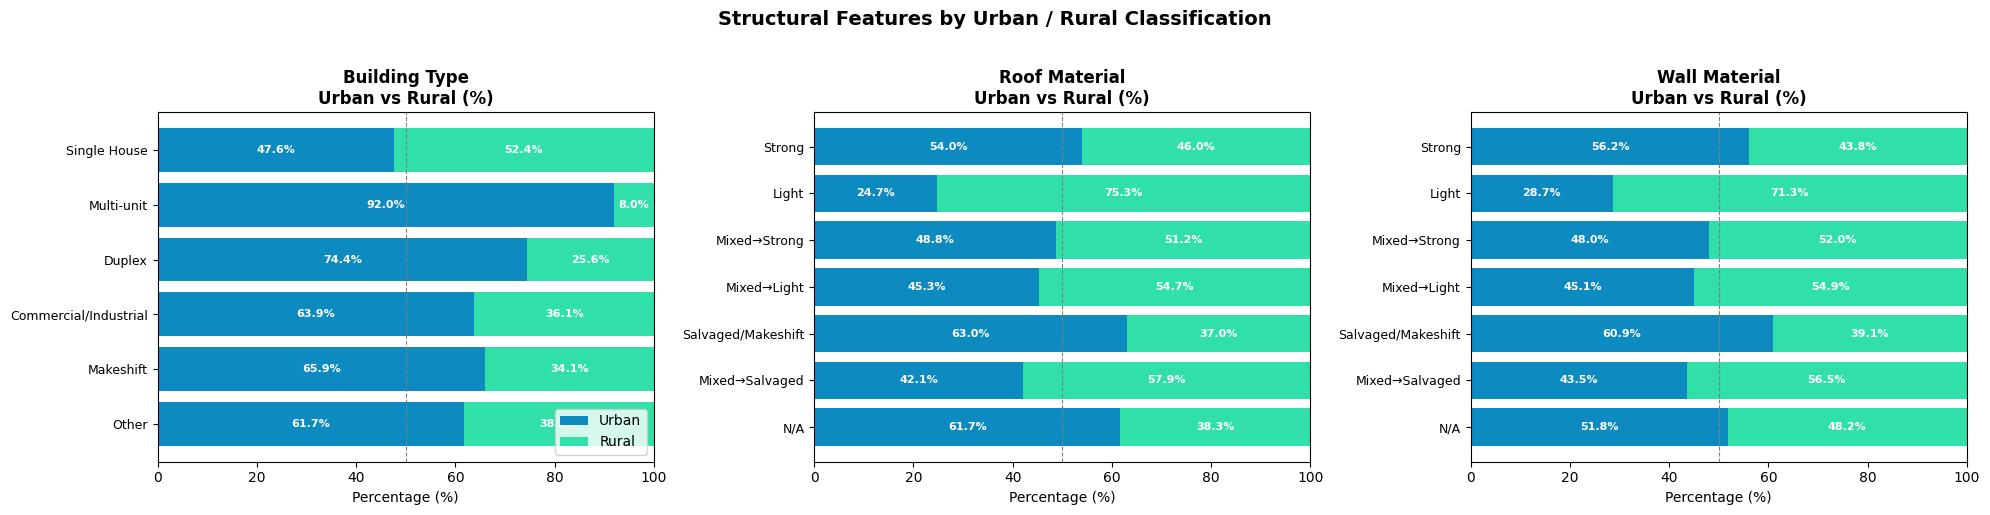

In [14]:

def stacked_pct_chart(ax, df, col, label_map, title, urb_col="URB_LABEL"):
    grouped = (
        df.groupby([col, urb_col])
        .size()
        .unstack(fill_value=0)
    )

    for c in ["Urban","Rural"]:
        if c not in grouped: grouped[c] = 0
    #grouped["Total"] = grouped["Urban"] + grouped["Rural"]
    #grouped = grouped.sort_values("Total", ascending=True)      # most common at top
    #grouped["Urban%"] = grouped["Urban"] / grouped["Total"] * 100
    #grouped["Rural%"] = grouped["Rural"] / grouped["Total"] * 100

    grouped["Total"] = grouped["Urban"] + grouped["Rural"]
    grouped = grouped.sort_values("Total", ascending=True)      # most common at top
    grouped["Rural_prop"] = (grouped["Rural"] / sum(grouped["Rural"])) * 100 # rural proportion
    grouped["Urban_prop"] = (grouped["Urban"] / sum(grouped["Urban"])) * 100 # urban proportion
    grouped["Urban%"] = (grouped["Urban_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100
    grouped["Rural%"] = (grouped["Rural_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100
    print(grouped)

    labels = [label_map.get(idx, str(idx)) for idx in grouped.index]
    y = np.arange(len(labels))

    ax.barh(y, grouped["Urban%"], color=urban_c, label="Urban")
    ax.barh(y, grouped["Rural%"], left=grouped["Urban%"], color=rural_c, label="Rural")

    for i in range(len(y)):
        u, r = grouped["Urban%"].iloc[i], grouped["Rural%"].iloc[i]
        if u >= 8:  ax.text(u/2,          i, f"{u:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        if r >= 8:  ax.text(u + r/2,      i, f"{r:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 100); ax.set_xlabel("Percentage (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))


stacked_pct_chart(axes[0], fies_subset_df_labeled, "BLDG_TYPE", BLDG_LABELS,
                  "Building Type\nUrban vs Rural (%)")
stacked_pct_chart(axes[1], fies_subset_df_labeled, "ROOF",      ROOF_LABELS,
                  "Roof Material\nUrban vs Rural (%)")
stacked_pct_chart(axes[2], fies_subset_df_labeled, "WALLS",     WALLS_LABELS,
                  "Wall Material\nUrban vs Rural (%)")

axes[0].legend(loc="lower right"); 
fig.suptitle("Structural Features by Urban / Rural Classification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


#### Amenity Distributions: Urban vs Rural
Toilet type, electricity access, and water source.

URB_LABEL  Rural  Urban  Total  Rural_prop  Urban_prop     Urban%     Rural%
TOILET                                                                      
7            367     92    459    1.479958    0.598452  28.793735  71.206265
4            645    318    963    2.601016    2.068562  44.298688  55.701312
6           1313    169   1482    5.294782    1.099330  17.192849  82.807151
0           1570    358   1928    6.331156    2.328758  26.891240  73.108760
3           1737    508   2245    7.004597    3.304495  32.054180  67.945820
5           2158    300   2458    8.702315    1.951473  18.317178  81.682822
2           1685   1716   3401    6.794903   11.162428  62.160841  37.839159
1          15323  11912  27235   61.791273   77.486502  55.634506  44.365494
URB_LABEL  Rural  Urban  Total  Rural_prop  Urban_prop     Urban%     Rural%
ELECTRIC                                                                    
2           4486    799   5285   18.090169    5.197424  22.318426  77.681574

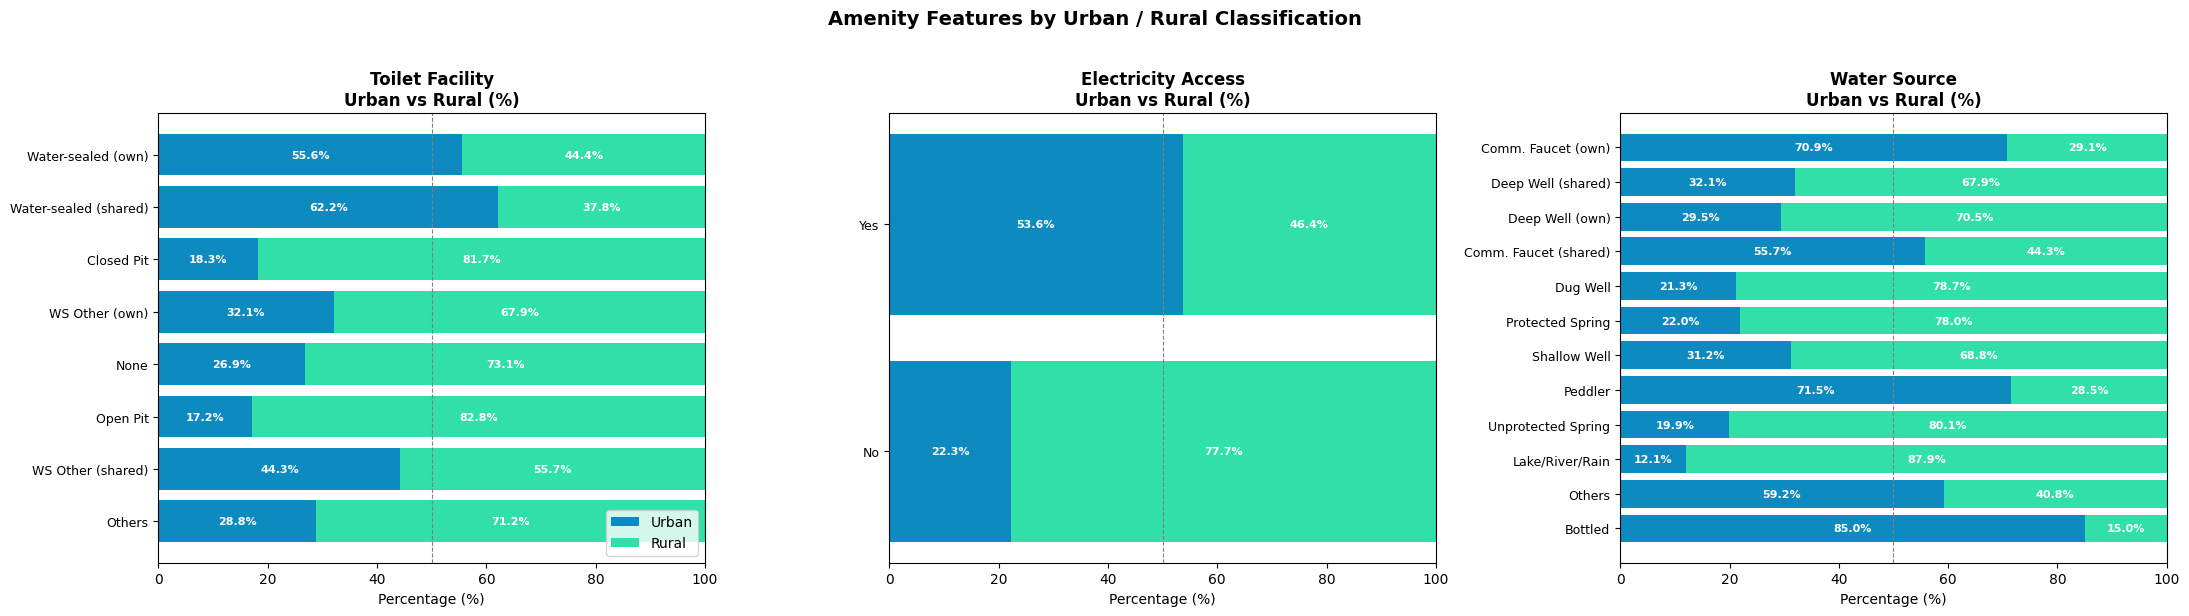

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

stacked_pct_chart(axes[0], fies_subset_df_labeled, "TOILET",   TOILET_LABELS,
                  "Toilet Facility\nUrban vs Rural (%)")
stacked_pct_chart(axes[1], fies_subset_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
                  "Electricity Access\nUrban vs Rural (%)")
stacked_pct_chart(axes[2], fies_subset_df_labeled, "WATER",    WATER_LABELS,
                  "Water Source\nUrban vs Rural (%)")

axes[0].legend(loc="lower right")
fig.suptitle("Amenity Features by Urban / Rural Classification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


#### Appliance & Vehicle Ownership: Urban vs Rural
Average ownership counts per household for appliances and vehicles.

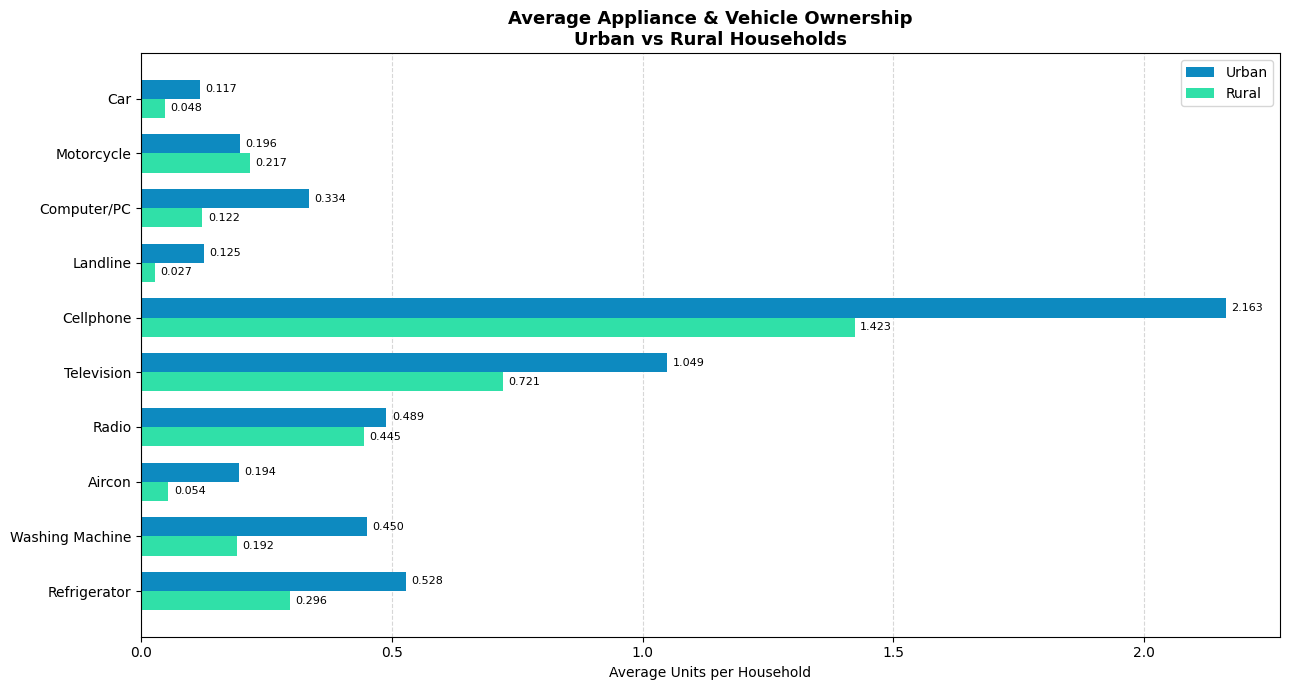

In [16]:

appliance_cols = {
    "CAR_QTY":        "Car",
    "MOTORCYCLE_QTY": "Motorcycle",
    "PC_QTY":         "Computer/PC",
    "LANDLINE_QTY":   "Landline",
    "CELLPHONE_QTY":  "Cellphone",
    "TV_QTY":         "Television",
    "RADIO_QTY":      "Radio",
    "AIRCON_QTY":     "Aircon",
    "WASH_QTY":       "Washing Machine",
    "REF_QTY":        "Refrigerator",
}

app_df = fies_subset_df_labeled[list(appliance_cols.keys()) + ["URB_LABEL"]].copy()
for col in appliance_cols:
    app_df[col] = pd.to_numeric(app_df[col], errors="coerce")

app_mean = (
    app_df
    .groupby("URB_LABEL")[list(appliance_cols.keys())]
    .mean()
    .rename(columns=appliance_cols)
    .T
)

n = len(app_mean)
y = np.arange(n)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
b_u = ax.barh(y - bar_h/2, app_mean["Urban"], height=bar_h, label="Urban", color=urban_c)
b_r = ax.barh(y + bar_h/2, app_mean["Rural"],  height=bar_h, label="Rural",  color=rural_c)

ax.bar_label(b_u, padding=4, fmt="{:.3f}", fontsize=8)
ax.bar_label(b_r, padding=4, fmt="{:.3f}", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(app_mean.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Average Units per Household")
ax.set_title("Average Appliance & Vehicle Ownership\nUrban vs Rural Households",
             fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


 ### **3.) Household Composition** 

Household Physical Composition (BLDG_TYPE, ROOF, WALLS, TOILET, ELECTRIC, WATER)

In [17]:
physical_features = ['BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# A. Statistical summaries
print("Physical Housing Composition Summaries")
for col in physical_features:
    if col in ws_or_na_df.columns:
        print(f"\nValue Counts for {col}:")
        print(ws_or_na_df[col].value_counts(normalize=True) * 100)

Physical Housing Composition Summaries

Value Counts for BLDG_TYPE:
BLDG_TYPE
1    94.503498
3     2.957357
2     2.392273
4     0.109532
5     0.027383
6     0.009957
Name: proportion, dtype: float64

Value Counts for ROOF:
ROOF
1    78.867840
2    13.698937
4     4.889099
5     1.924274
3     0.465510
6     0.144383
7     0.009957
Name: proportion, dtype: float64

Value Counts for WALLS:
WALLS
1    66.172114
2    20.407757
4     8.543477
5     3.778845
3     0.831446
6     0.253915
7     0.012447
Name: proportion, dtype: float64

Value Counts for TOILET:
TOILET
1    67.797665
2     8.466307
5     6.118842
3     5.588609
0     4.799482
6     3.689229
4     2.397252
7     1.142615
Name: proportion, dtype: float64

Value Counts for ELECTRIC:
ELECTRIC
1    86.843743
2    13.156257
Name: proportion, dtype: float64

Value Counts for WATER:
WATER
1     37.868114
4     16.118593
3     11.963855
2     11.030345
6      8.643051
7      5.060865
5      3.519952
10     2.068656
8      1.824699
9 

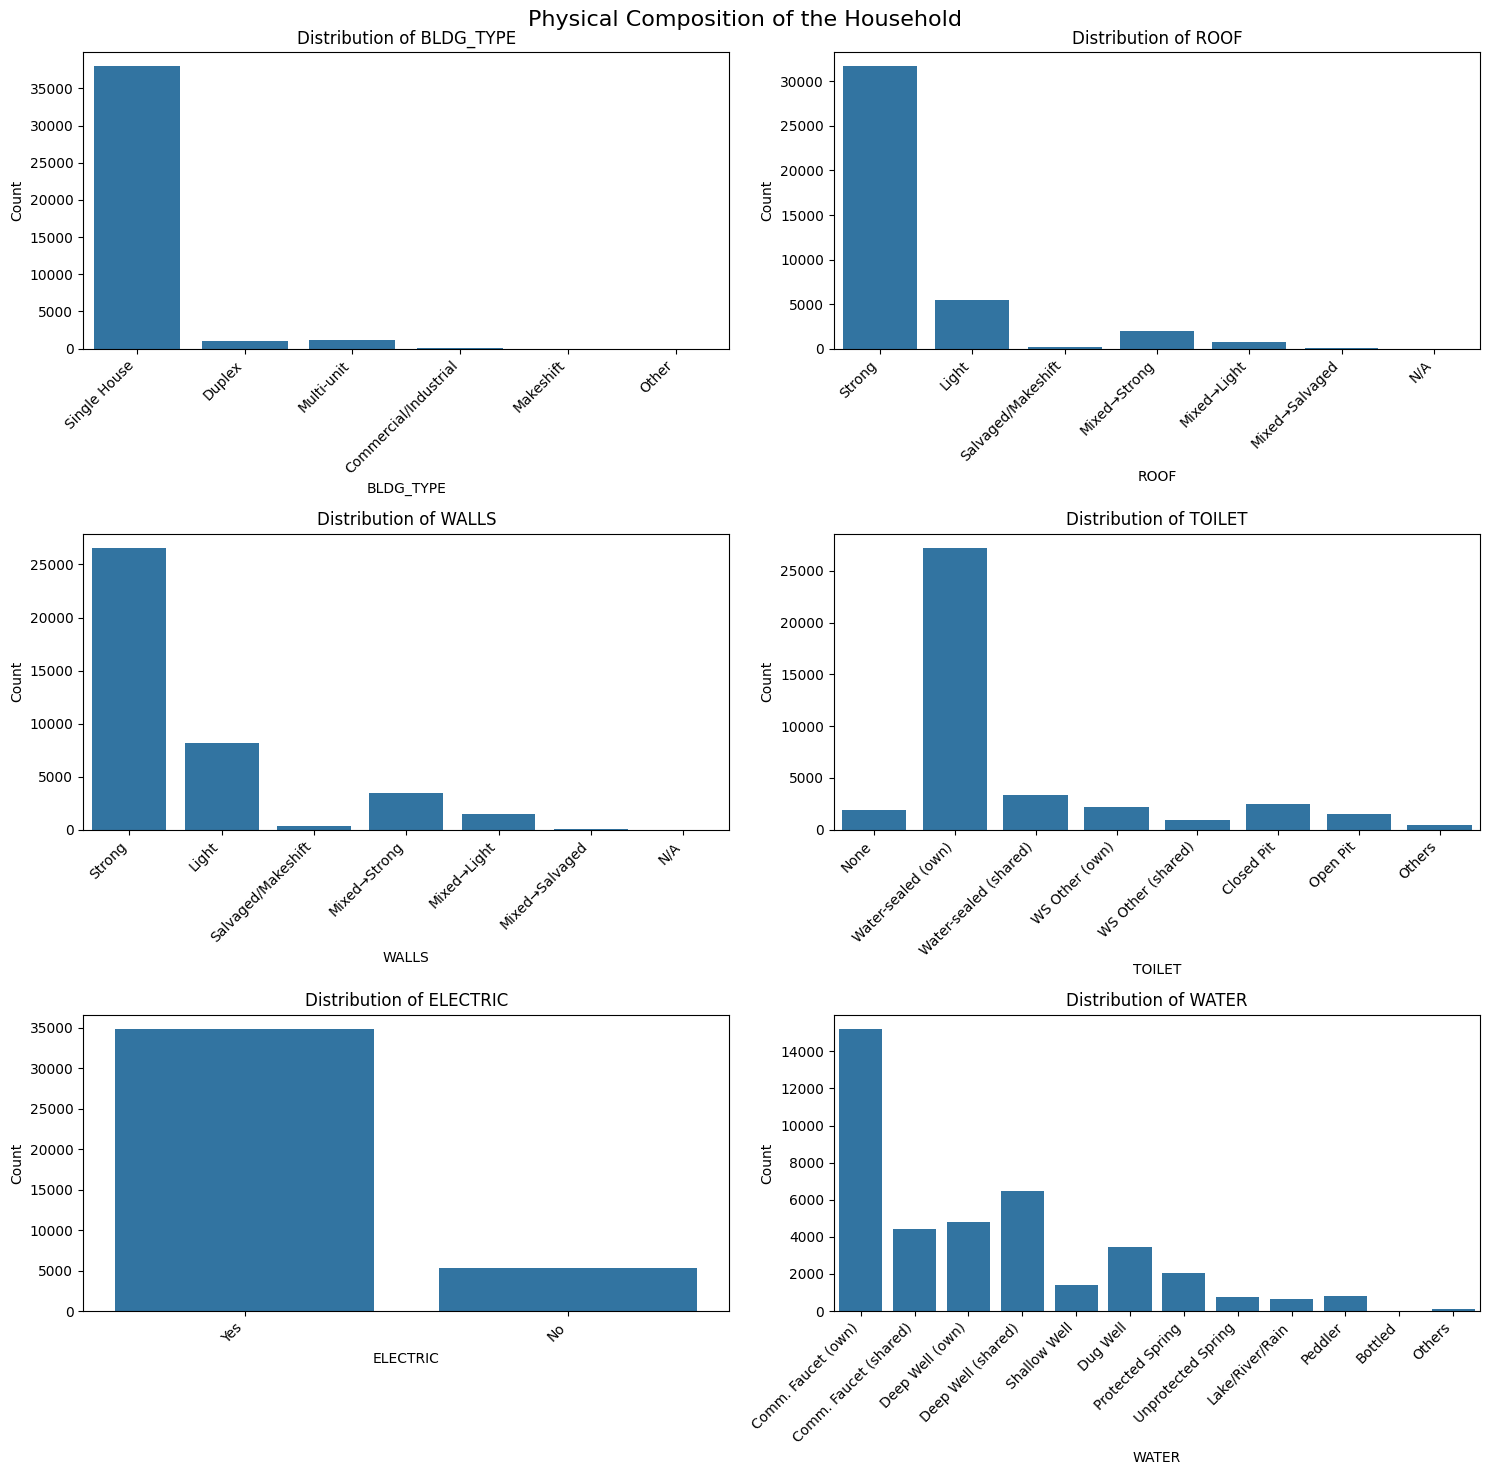

In [18]:
# B. Visualizing Physical Housing Composition (Categorical)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Physical Composition of the Household', fontsize=16)

def set_xtick_labels(labels):
    ax.set_xticks([float(x) for x in range(0, len(labels))])
    ax.set_xticklabels(list(labels.values()), rotation=45, ha='right')

for i, col in enumerate(physical_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]
        sns.countplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.tick_params(axis='x', rotation=45) 
        ax.set_ylabel('Count')

        if col=="BLDG_TYPE":
            set_xtick_labels(BLDG_LABELS)
        if col=="ROOF":
            set_xtick_labels(ROOF_LABELS)
        if col=="WALLS":
            set_xtick_labels(WALLS_LABELS)
        if col=="TOILET":
            set_xtick_labels(TOILET_LABELS)
        if col=="ELECTRIC":
            set_xtick_labels(ELECTRIC_LABELS)
        if col=="WATER":
            set_xtick_labels(WATER_LABELS)
        
plt.tight_layout()
plt.show()

Household Asset Composition

In [19]:
asset_features = ['CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 'CELLPHONE_QTY', 
                  'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 'WASH_QTY', 'REF_QTY']

# A. Statistical summaries
print("\nHousehold Asset Composition Summaries")
display(ws_or_na_df[asset_features].describe())


Household Asset Composition Summaries


,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
count,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000
mean,0.074332,0.209081,0.203306,0.064499,1.706082,0.846432,0.461701,0.107764,0.290682,0.384979
std,0.326798,0.487354,0.537806,0.279669,1.543661,0.654158,0.535887,0.410240,0.467002,0.535224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,6.000000,11.000000,6.000000,5.000000,14.000000,7.000000,5.000000,8.000000,6.000000,5.000000


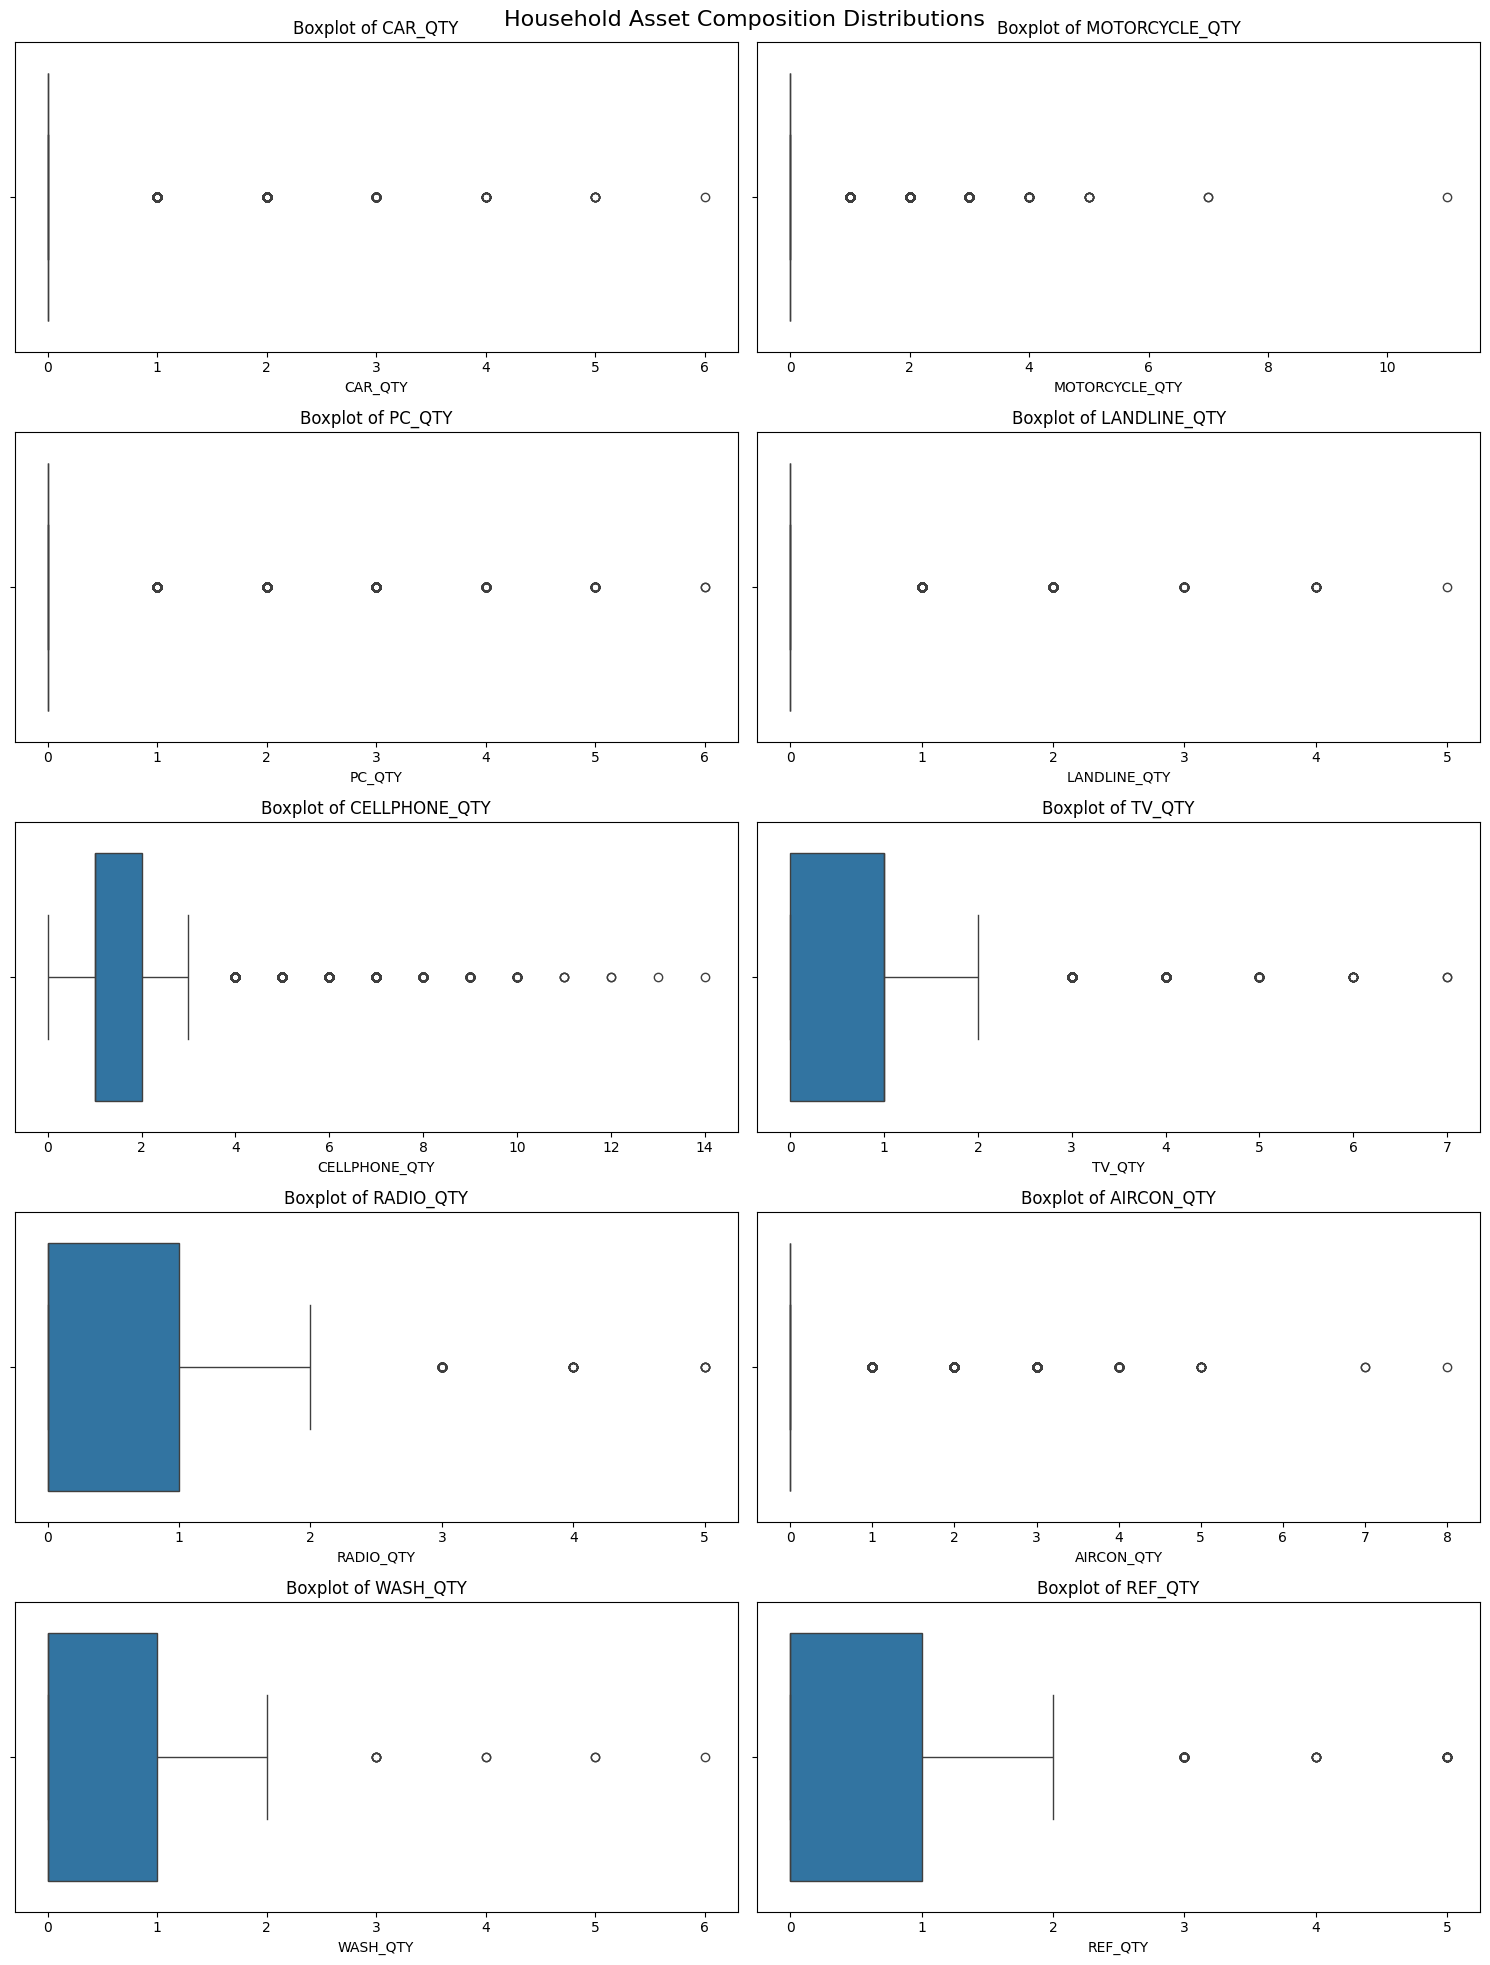

In [20]:
# B. Visualizing Asset/Appliance Quantities (Numerical)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle('Household Asset Composition Distributions', fontsize=16)

for i, col in enumerate(asset_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]

        # Using a boxplot to easily spot outliers
        sns.boxplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

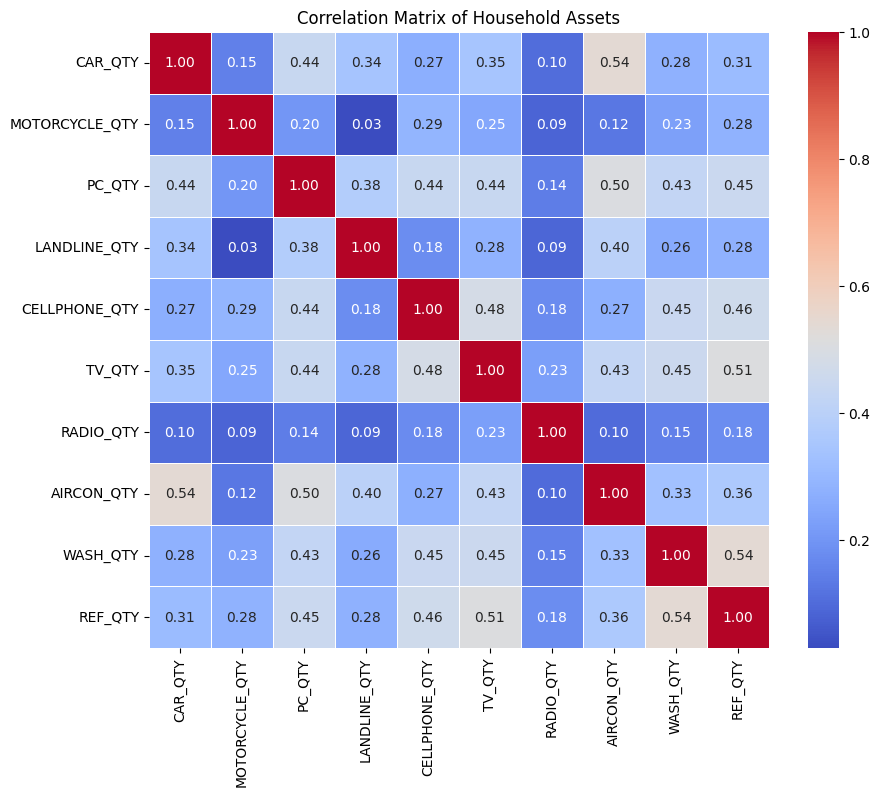

In [21]:
# C. Asset Correlation Heatmap 
# To see if owning certain items correlates with owning others
plt.figure(figsize=(10, 8))

# Coercing errors to NaN due to non-numeric entries (should we move this earlier?)
df_assets_numeric = ws_or_na_df[asset_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = df_assets_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Household Assets')
plt.show()

# **[3]** Data Preprocessing
In this phase, we will prepare our dataset for the machine learning models. This involves converting our target variable to a standard binary format, testing and handling of outliers, handling nominal categorical variables through One-Hot Encoding, splitting the data into training, validation, and test sets to prevent data leakage, and standardizing our numerical features.

### 1. Target Variable Encoding
Currently, our target variable `URB` is encoded as `1` for Urban and `2` for Rural. Supervised machine learning algorithms generally expect binary classification targets to be represented as `0` and `1`. We will remap the Rural category from `2` to `0`.

In [22]:
# Map URB: 1 remains 1 (Urban), 2 becomes 0 (Rural)
fies_subset_df['URB'] = fies_subset_df['URB'].replace(2, 0)

# Verify the changes
print("Target Variable Distribution (1 = Urban, 0 = Rural):")
print(fies_subset_df['URB'].value_counts())

Target Variable Distribution (1 = Urban, 0 = Rural):
URB
0    24798
1    15373
Name: count, dtype: int64


### 2. Handling Extreme Outliers (Log Transformation)
To determine if our continuous financial features require transformation before modeling, we will visualize the distribution of Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`).

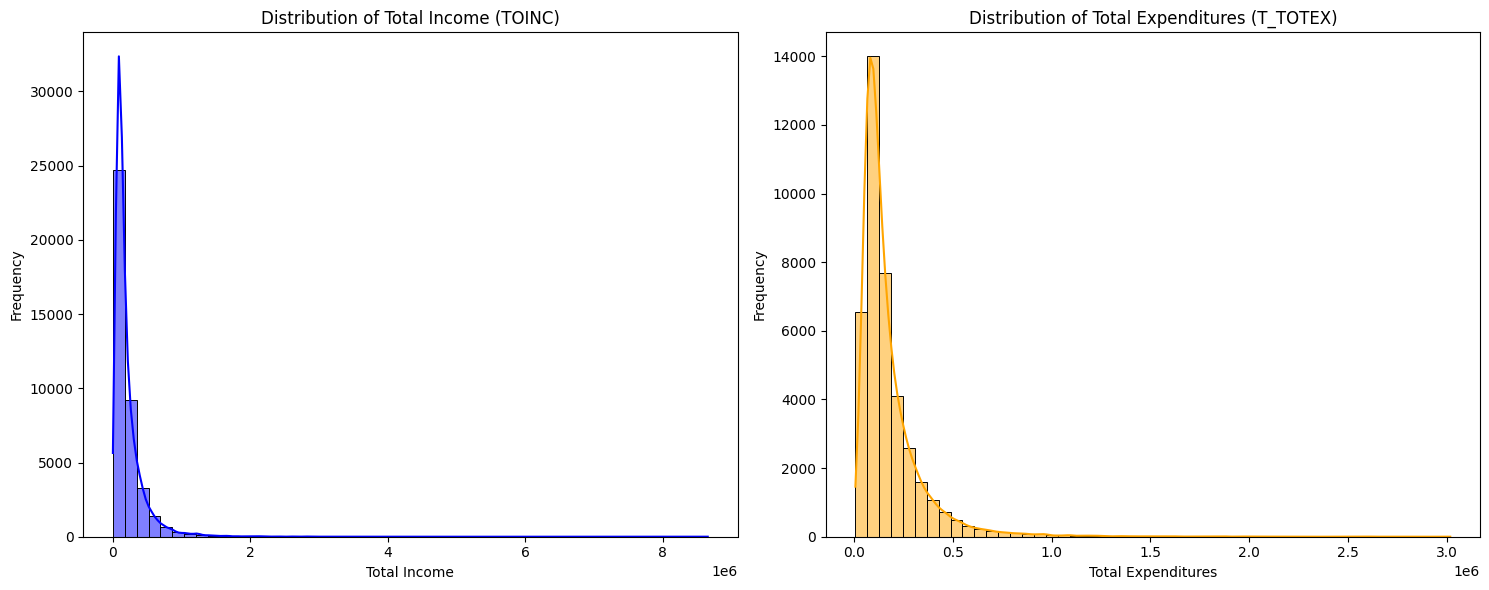

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Total Income
sns.histplot(fies_subset_df['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Income (TOINC)')
axes[0].set_xlabel('Total Income')
axes[0].set_ylabel('Frequency')

# Plot Total Expenditure
sns.histplot(fies_subset_df['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
axes[1].set_xlabel('Total Expenditures')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Financial features such as income (`Toinc`) and total expenditures (`T_TOTEX`) are highly right-skewed, meaning a small number of extremely wealthy households act as massive outliers. These extreme values can prevent our classical models and neural networks from learning effectively. 

Instead of dropping these valid data points, we will apply a Logarithmic Transformation (`np.log1p`) to all financial columns. This mathematical transformation pulls extreme values closer to the median, creating a more normalized, "bell-shaped" distribution that machine learning algorithms handle much better. We use `log1p` (which calculates $log(1+x)$) to avoid errors when taking the log of a feature with a value of exactly 0.

In [24]:
# Isolate the financial columns (Income and Expenditures)
# We exclude 'TOILET' just in case the string matcher accidentally catches it
financial_cols = [col for col in fies_subset_df.columns if col.startswith(('T_', 'NET_', 'REGFT', 'EAINC', 'TOINC')) and col != 'TOILET']

# Apply log1p transformation to these specific columns
for col in financial_cols:
    fies_subset_df[col] = np.log1p(fies_subset_df[col])

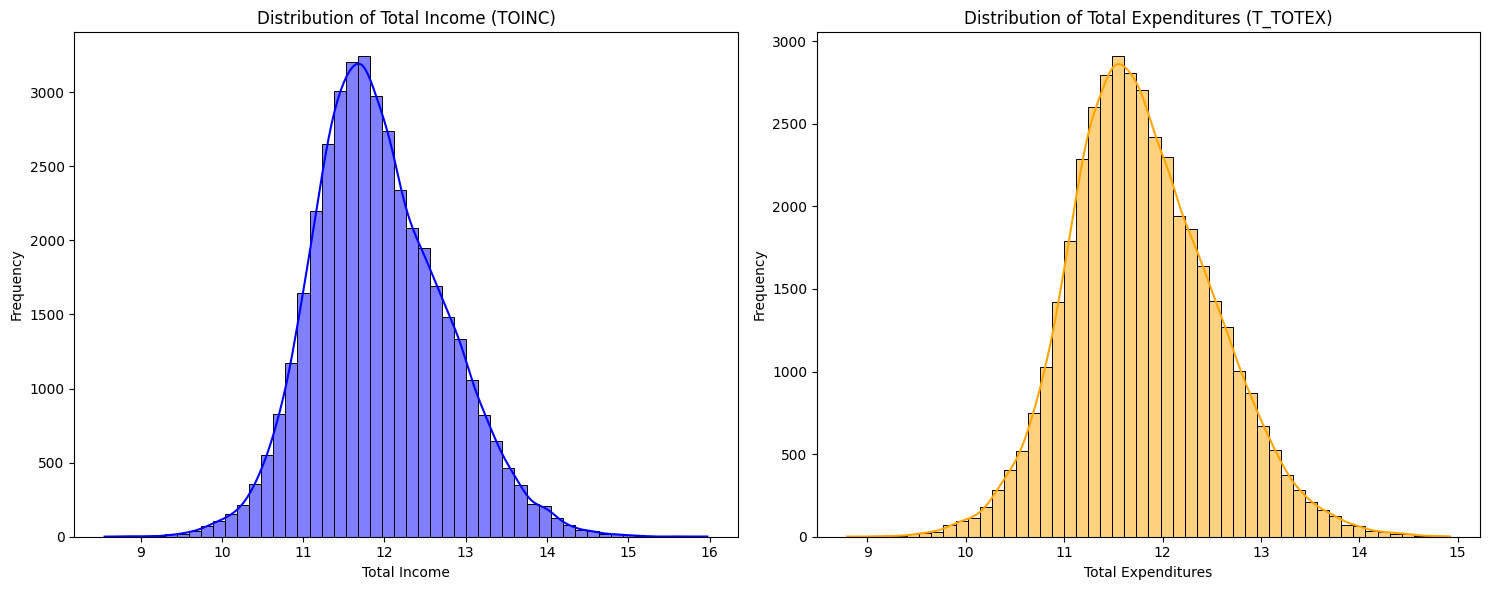

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Total Income
sns.histplot(fies_subset_df['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Income (TOINC)')
axes[0].set_xlabel('Total Income')
axes[0].set_ylabel('Frequency')

# Plot Total Expenditure
sns.histplot(fies_subset_df['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
axes[1].set_xlabel('Total Expenditures')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3. One-Hot Encoding Categorical Features
Our dataset contains several nominal categorical features: `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Leaving these as arbitrary numbers might cause algorithms to incorrectly assume they have a mathematical hierarchy (e.g., Region 5 is "greater" than Region 2). 

To fix this, we apply One-Hot Encoding to convert them into binary indicator variables. We also use `drop_first=True` to drop the first category of each feature. This prevents multicollinearity (the "dummy variable trap"), which is highly beneficial for classical machine learning models like Logistic Regression.

In [26]:
# Define categorical columns
categorical_cols = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Apply One-Hot Encoding
fies_encoded_df = pd.get_dummies(fies_subset_df, columns=categorical_cols, drop_first=True, dtype=int)

# Check the new shape of the dataset
print(f"Original subset shape: {fies_subset_df.shape}")
print(f"Encoded dataset shape: {fies_encoded_df.shape}")

Original subset shape: (40171, 44)
Encoded dataset shape: (40171, 89)


### 4. Train-Validation-Test Split
According to the project specifications, we must ensure proper training-validation-test splits to avoid data leakage. 
* **Training Set (70%):** Used to train our classical models and neural network.
* **Validation Set (15%):** Used to tune hyperparameters and evaluate the models during training.
* **Test Set (15%):** Used for the final, unbiased evaluation of our models.

We will use the `stratify` parameter to ensure the proportion of Urban and Rural households remains perfectly balanced across all three splits.

In [27]:
# Separate Features (X) and Target (y)
X = fies_encoded_df.drop('URB', axis=1)
y = fies_encoded_df['URB']

# First split: 70% Train, 30% Temporary (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Divide the 30% Temporary set equally into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 28119 samples
Validation set: 6026 samples
Testing set: 6026 samples


### 5. Feature Scaling (Using RobustScaler)
Our features operate on vastly different scales. While our financial features have been log-transformed, our asset counts (like `CAR_QTY`) still range from 0 to 5, and our One-Hot Encoded variables are binary (0 or 1). 

Machine learning algorithms—especially Neural Networks and distance-based classical models—require features to be on a similar scale to converge properly. Because we still have some lingering outliers even after the log transformation, we will use `RobustScaler` instead of `StandardScaler`. `RobustScaler` scales the data using the median and the Interquartile Range (IQR), making it completely immune to extreme outliers.

**Important Data Leakage Prevention:** The scaler must be fitted *only* on the training data. We then apply that learned transformation to the validation and test sets.

In [28]:
# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test sets using the previously fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# **[4]** Model Selection Training


## Classical machine learning model #1

## Classical machine learning model #2

## Classical machine learning model #3

### Model Selection and Training
For the second model, we are implementing a **Random Forest Classifier**. This is a powerful ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It is naturally robust to non-linear relationships and will help us easily interpret which socioeconomic features are most important for predicting urbanization.</br></br>

To initialize our model, we set `andom_state` to 42 so we can ensure our results are reproducible for every run. `n_jobs` parameter determines the number of CPU cores to use for running parallel processes. We set it to `-1` to use all available CPU cores, maximizing the potential speed benefit.

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the scaled training data
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model successfully trained!")

Random Forest model successfully trained!


### Error Analysis and Model Tuning
Before finalizing our Random Forest, we need to analyze where our baseline model makes mistakes. We will generate predictions on our **Validation Set** and evaluate it using our 7 chosen metrics: Accuracy, Precision, Recall, F1-Score, Confusion Matrix, AUC-ROC, and AUC-PR.

--- Baseline Random Forest Metrics (Validation Set) ---
1) Accuracy:  0.8063
2) Precision: 0.7952
3) Recall:    0.6652
4) F1 Score:  0.7244
6) AUC-ROC:   0.8782
7) AUC-PR:    0.8438



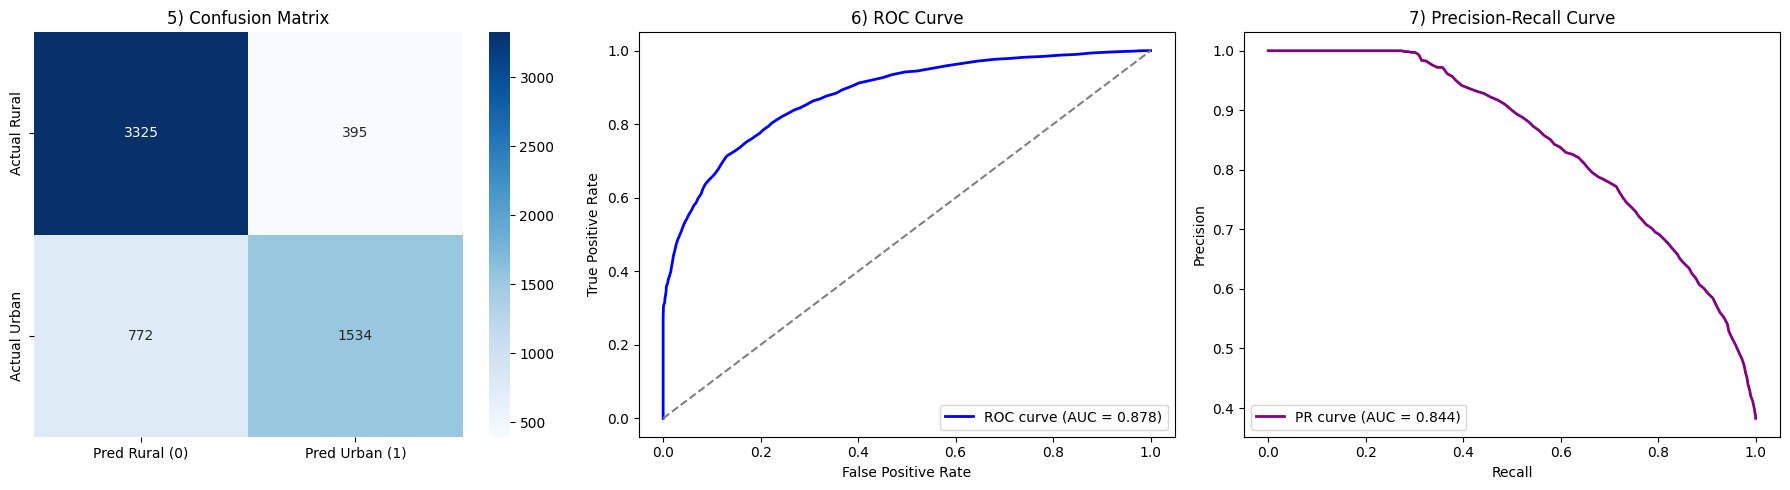

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, average_precision_score, 
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Get standard predictions (0 or 1) and probability predictions
rf_y_val_pred = rf_model.predict(X_val_scaled)
rf_y_val_prob = rf_model.predict_proba(X_val_scaled)[:, 1] # Probability of Class 1 (Urban)

# Calculate single-number metrics
rf_acc = accuracy_score(y_val, rf_y_val_pred)
rf_prec = precision_score(y_val, rf_y_val_pred)
rf_rec = recall_score(y_val, rf_y_val_pred)
rf_f1 = f1_score(y_val, rf_y_val_pred)
rf_roc_auc = roc_auc_score(y_val, rf_y_val_prob)
rf_pr_auc = average_precision_score(y_val, rf_y_val_prob)

print("Baseline Random Forest Metrics (Validation Set)")
print(f"1) Accuracy:  {rf_acc:.4f}")
print(f"2) Precision: {rf_prec:.4f}")
print(f"3) Recall:    {rf_rec:.4f}")
print(f"4) F1 Score:  {rf_f1:.4f}")
print(f"6) AUC-ROC:   {rf_roc_auc:.4f}")
print(f"7) AUC-PR:    {rf_pr_auc:.4f}\n")

# Plotting the Visual Metrics (Confusion Matrix, ROC, PR)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_val, rf_y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Rural (0)', 'Pred Urban (1)'], 
            yticklabels=['Actual Rural', 'Actual Urban'])
axes[0].set_title('5) Confusion Matrix')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_val, rf_y_val_prob)
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {rf_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('6) ROC Curve')
axes[1].legend(loc="lower right")

# Plot C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, rf_y_val_prob)
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {rf_pr_auc:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('7) Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Hyperparameter Tuning (Grid Search)
Based on the error analysis above, we will now perform tune our model to optimize our F1-Score. We are using `GridSearchCV` to systematically test a grid of different hyperparameter combinations (number of trees, maximum depth, and minimum samples per split) using 3-fold Cross-Validation.

**Why optimize for the F1-Score?**
We are specifically telling our Grid Search to optimize for the **F1-Score** rather than standard Accuracy for three critical reasons:
1. **Imbalanced Data:** Our dataset is imbalanced. If there are more urban households than rural ones, a model could achieve high Accuracy simply by guessing "Urban" every time. The F1-Score prevents this by severely penalizing the model if it ignores the minority class.
2. **Balancing the Trade-off:** Optimizing solely for Precision would make the model too cautious (resulting in high false negatives), while optimizing for Recall would make it "trigger-happy" (resulting in high false positives). 
3. **The Harmonic Mean:** Because the F1-Score is the harmonic mean of Precision and Recall, it forces the Grid Search to find the specific hyperparameter combination that confidently identifies urban homes *without* sacrificing its ability to accurately classify rural homes.

In [31]:
from sklearn.model_selection import GridSearchCV

# Defining the grid of hyperparameters to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',       # Optimizing for F1-Score
    cv=3,               
    n_jobs=-1,
    verbose=2           
)

# Fit the Grid Search to the training data
grid_search.fit(X_train_scaled, y_train)

# Extract the best model
best_rf_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validation F1-Score: 0.7358


### Final Model Evaluation
With our model fully tuned, we will now perform our final evaluation using the isolated test set. This provides an unbiased look at how our optimized Random Forest will perform on completely unseen household data.

Final Tuned Random Forest Metrics (Test Set)
1) Accuracy:  0.8160
2) Precision: 0.8152
3) Recall:    0.6713
4) F1 Score:  0.7363
6) AUC-ROC:   0.8864
7) AUC-PR:    0.8574



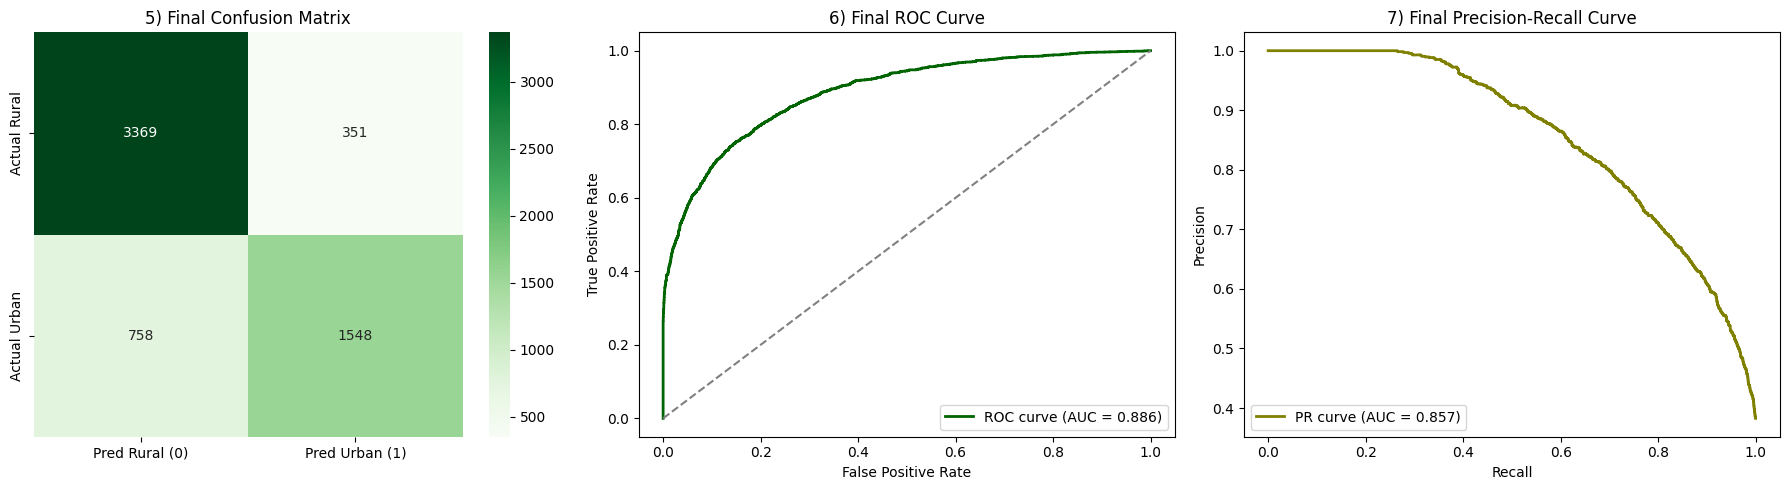

In [35]:
# Use the best model from Grid Search to predict the test set
rf_y_test_pred = best_rf_model.predict(X_test_scaled)
rf_y_test_prob = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate final metrics
rf_test_acc = accuracy_score(y_test, rf_y_test_pred)
rf_test_prec = precision_score(y_test, rf_y_test_pred)
rf_test_rec = recall_score(y_test, rf_y_test_pred)
rf_test_f1 = f1_score(y_test, rf_y_test_pred)
rf_test_roc_auc = roc_auc_score(y_test, rf_y_test_prob)
rf_test_pr_auc = average_precision_score(y_test, rf_y_test_prob)

print("Final Tuned Random Forest Metrics (Test Set)")
print(f"1) Accuracy:  {rf_test_acc:.4f}")
print(f"2) Precision: {rf_test_prec:.4f}")
print(f"3) Recall:    {rf_test_rec:.4f}")
print(f"4) F1 Score:  {rf_test_f1:.4f}")
print(f"6) AUC-ROC:   {rf_test_roc_auc:.4f}")
print(f"7) AUC-PR:    {rf_test_pr_auc:.4f}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Final Confusion Matrix
cm_test = confusion_matrix(y_test, rf_y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['Pred Rural (0)', 'Pred Urban (1)'], 
            yticklabels=['Actual Rural', 'Actual Urban'])
axes[0].set_title('5) Final Confusion Matrix')

# Plot B: Final ROC Curve
fpr_test, tpr_test, _ = roc_curve(y_test, rf_y_test_prob)
axes[1].plot(fpr_test, tpr_test, color='darkgreen', lw=2, label=f'ROC curve (AUC = {rf_test_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('6) Final ROC Curve')
axes[1].legend(loc="lower right")

# Plot C: Final Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, rf_y_test_prob)
axes[2].plot(recall_test, precision_test, color='olive', lw=2, label=f'PR curve (AUC = {rf_test_pr_auc:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('7) Final Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Feature Importance Analysis
One of the primary advantages of the Random Forest algorithm is its interpretability. Below, we extract the feature importances from our best model to understand which household characteristics were the strongest predictors of urbanization.

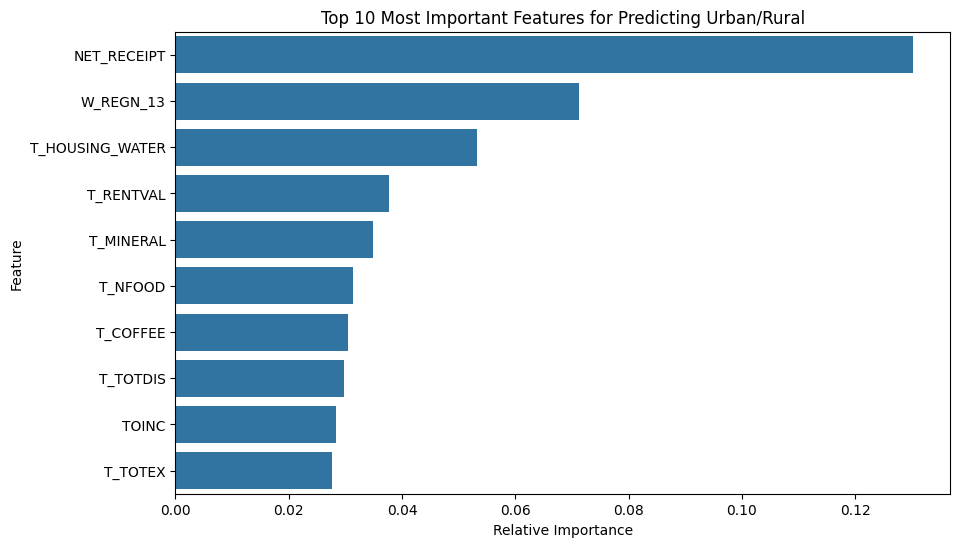

In [39]:
# Extract feature importances from the tuned model
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Most Important Features for Predicting Urban/Rural')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

## Neural Network model #1


## Neural Network model #2

# **[5]** Error Analysis and Model Tuning
sample text here

# **[6]** Model Evaluation
sample text here

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text